# Baseline Backtest Viewer

Opens the latest canonical baseline-family run, currently resolved from `research/configs/baselines/backtest_current_baseline.json`.

Use this notebook for the stable baseline portfolio view: summary statistics, equity curve, holdings, concentration, order flow, and trading costs.


In [1]:
# Options: 'current_baseline_family' or 'latest_run'
RUN_SELECTION_MODE = 'current_baseline_family'


In [2]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')


def _resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'research/configs/baselines/backtest_current_baseline.json').exists():
            return candidate
    return cwd


REPO_ROOT = _resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from research.common.backtest_viewer import build_viewer_context

# Set MANUAL_RUN_DIR to pin a specific run, for example:
# MANUAL_RUN_DIR = 'eval_results/backtest/ab_pairs/<pair_dir>/run_b'
MANUAL_RUN_DIR = None

context = build_viewer_context(
    run_selection_mode=RUN_SELECTION_MODE,
    manual_run_dir=MANUAL_RUN_DIR,
    repo_root=REPO_ROOT,
)

BACKTEST_ROOT = context.backtest_root
BASELINE_CONFIG_PATH = context.baseline_config_path
RUNS = context.runs
LATEST_RUN_DIR = context.latest_run_dir
LATEST_CURRENT_BASELINE_DIR = context.latest_current_baseline_dir
DEFAULT_RUN_DIR = context.default_run_dir
top = context.run_table

display(top)


,rank,run_dir,source,pair,has_daily_market_value,summary_end_date,latest_trade_date,completed_at
0,1,/home/rockebull/proj/TradingAgents/eval_result...,single,None,True,2026-07-17,2026-06-30,2026-07-17 23:00:43.729777575
1,2,/home/rockebull/proj/TradingAgents/eval_result...,single,None,True,2026-07-17,2026-06-30,2026-07-17 22:41:58.900956154
2,3,/home/rockebull/proj/TradingAgents/eval_result...,ab_run_b,20260628T134003Z_baseline_vs_defensive_sleeve_v2,True,2026-06-27,2026-05-29,2026-06-28 13:40:39.423280716
3,4,/home/rockebull/proj/TradingAgents/eval_result...,ab_run_a,20260628T134003Z_baseline_vs_defensive_sleeve_v2,True,2026-06-27,2026-05-29,2026-06-28 13:40:18.810796261
4,5,/home/rockebull/proj/TradingAgents/eval_result...,single,None,True,2026-06-10,2026-05-29,2026-06-28 13:23:32.966992855
5,6,/home/rockebull/proj/TradingAgents/eval_result...,single,None,True,2026-06-10,2026-05-29,2026-06-28 13:23:13.572637558
6,7,/home/rockebull/proj/TradingAgents/eval_result...,single,None,True,2026-06-10,2026-05-29,2026-06-28 13:22:53.835413218
7,8,/home/rockebull/proj/TradingAgents/eval_result...,single,None,True,2026-06-10,2026-05-29,2026-06-28 13:22:33.931152821
8,9,/home/rockebull/proj/TradingAgents/eval_result...,single,None,True,2026-06-27,2026-06-26,2026-06-27 11:58:34.826025724
9,10,/home/rockebull/proj/TradingAgents/eval_result...,single,None,True,2026-06-27,2026-06-24,2026-06-27 11:31:43.473652840


In [3]:
RUN_DIR = Path(DEFAULT_RUN_DIR)
artifacts = context.artifacts

summary = artifacts.summary
eq = artifacts.equity_curve
daily_eq = artifacts.daily_market_value
weights_history = artifacts.weights_history
orders_history = artifacts.orders_history

print('Run selection mode:', RUN_SELECTION_MODE)
print('Selected run:', RUN_DIR)
print('Date window:', summary.get('start_date'), '->', summary.get('end_date'))
print('Latest trade date:', eq['trade_date'].max())
print('Has daily_market_value:', daily_eq is not None)
print('Has weights_history:', weights_history is not None)
print('Has orders_history:', orders_history is not None)


Run selection mode: current_baseline_family
Selected run: /home/rockebull/proj/TradingAgents/eval_results/backtest/current_baseline
Date window: 2021-06-27 -> 2026-07-17
Latest trade date: 2026-06-30 00:00:00
Has daily_market_value: True
Has weights_history: True
Has orders_history: True


In [4]:
summary_keys = [
    'total_return', 'cagr', 'annualized_volatility', 'sharpe', 'max_drawdown',
    'tracking_error', 'realized_active_information_ratio',
    'average_ic', 'average_breadth_proxy', 'average_transfer_coefficient',
    'average_transfer_coefficient_corrected', 'average_transfer_coefficient_legacy_proxy',
    'implied_information_ratio',
    'average_raw_turnover', 'average_executed_turnover', 'average_turnover_constraint_drag',
    'rebalance_points', 'final_nav', 'initial_capital'
]
summary_view = pd.DataFrame([
    {'metric': k, 'value': summary.get(k)} for k in summary_keys if k in summary
])
if {'average_transfer_coefficient_corrected', 'average_transfer_coefficient_legacy_proxy'} <= set(summary_view['metric']):
    corrected = float(summary.get('average_transfer_coefficient_corrected'))
    legacy = float(summary.get('average_transfer_coefficient_legacy_proxy'))
    summary_view = pd.concat([
        summary_view,
        pd.DataFrame([
            {'metric': 'transfer_coefficient_gap_legacy_minus_corrected', 'value': legacy - corrected},
            {'metric': 'transfer_coefficient_ratio_corrected_vs_legacy', 'value': corrected / legacy if legacy else float('nan')},
        ])
    ], ignore_index=True)
summary_view


,metric,value
0,total_return,3.828960e+00
1,cagr,4.948614e-01
2,annualized_volatility,2.606607e-01
3,sharpe,1.811575e+00
4,max_drawdown,-1.455538e-01
5,tracking_error,1.606761e-01
6,realized_active_information_ratio,1.692028e+00
7,average_ic,3.997333e-02
8,average_breadth_proxy,2.418074e+01
9,average_transfer_coefficient,3.624542e-01


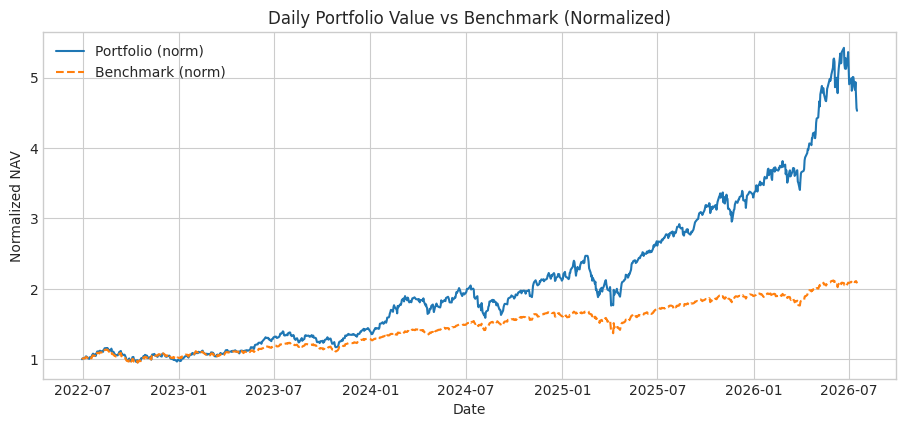

In [5]:
eq_plot = daily_eq.copy() if daily_eq is not None else eq.copy()
if daily_eq is not None:
    eq_plot['portfolio_nav_norm'] = eq_plot['portfolio_value'] / float(eq_plot['portfolio_value'].iloc[0])
    eq_plot['benchmark_nav_norm'] = eq_plot['benchmark_value'] / float(eq_plot['benchmark_value'].iloc[0])
    plot_title = 'Daily Portfolio Value vs Benchmark (Normalized)'
else:
    eq_plot['portfolio_nav_norm'] = eq_plot['nav'] / float(eq_plot['nav'].iloc[0])
    eq_plot['benchmark_nav_norm'] = (1.0 + pd.to_numeric(eq_plot['benchmark_return'], errors='coerce').fillna(0.0)).cumprod()
    plot_title = 'Equity Curve vs Benchmark (Normalized)'

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(eq_plot['trade_date'], eq_plot['portfolio_nav_norm'], label='Portfolio (norm)')
ax.plot(eq_plot['trade_date'], eq_plot['benchmark_nav_norm'], label='Benchmark (norm)', linestyle='--')
ax.set_title(plot_title)
ax.set_xlabel('Date')
ax.set_ylabel('Normalized NAV')
ax.legend()
plt.show()


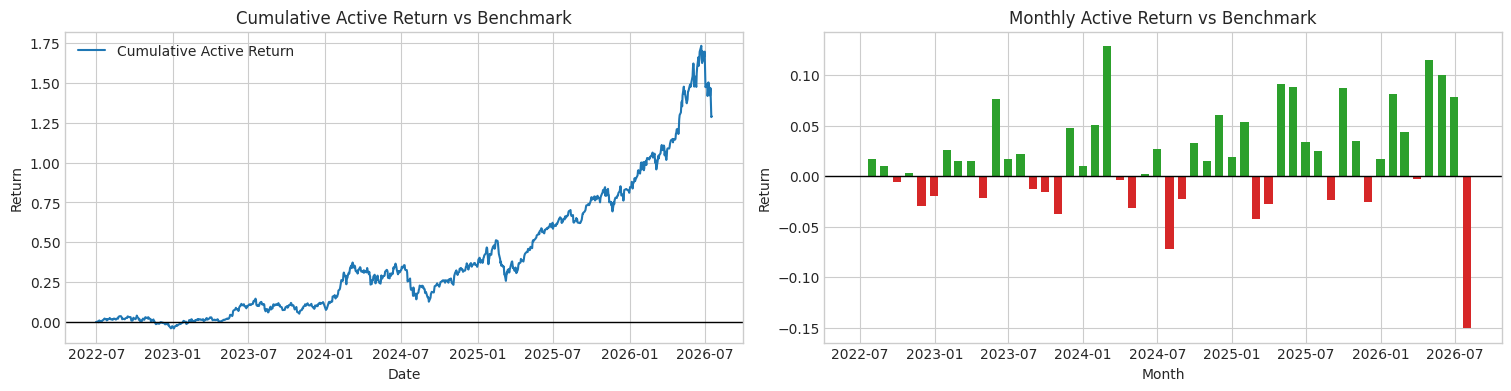

In [6]:
eq_plot = daily_eq.copy() if daily_eq is not None else eq.copy()
eq_plot['active_return'] = pd.to_numeric(eq_plot['portfolio_return'], errors='coerce').fillna(0.0) - pd.to_numeric(eq_plot['benchmark_return'], errors='coerce').fillna(0.0)
eq_plot['cum_active_return'] = (1.0 + eq_plot['active_return']).cumprod() - 1.0
monthly_active = (
    eq_plot.set_index('trade_date')['active_return']
    .resample('ME')
    .apply(lambda s: (1.0 + s).prod() - 1.0)
    .rename('monthly_active_return')
    .reset_index()
)
monthly_active['bar_color'] = monthly_active['monthly_active_return'].apply(lambda v: '#2ca02c' if v >= 0 else '#d62728')

fig, axes = plt.subplots(1, 2, figsize=(15, 3.8), constrained_layout=True)

axes[0].plot(eq_plot['trade_date'], eq_plot['cum_active_return'], label='Cumulative Active Return')
axes[0].axhline(0.0, color='black', linewidth=1)
axes[0].set_title('Cumulative Active Return vs Benchmark')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Return')
axes[0].legend()

axes[1].bar(
    monthly_active['trade_date'],
    monthly_active['monthly_active_return'],
    width=20,
    color=monthly_active['bar_color'],
)
axes[1].axhline(0.0, color='black', linewidth=1)
axes[1].set_title('Monthly Active Return vs Benchmark')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Return')

plt.show()


In [7]:
cost_series = pd.to_numeric(eq['cost'], errors='coerce').fillna(0.0) if 'cost' in eq.columns else pd.Series(0.0, index=eq.index)
turnover_series = pd.to_numeric(eq['turnover'], errors='coerce').fillna(0.0) if 'turnover' in eq.columns else pd.Series(0.0, index=eq.index)
raw_turnover_series = pd.to_numeric(eq['raw_turnover'], errors='coerce').fillna(0.0) if 'raw_turnover' in eq.columns else pd.Series(0.0, index=eq.index)

execution_summary = pd.DataFrame([
    {'metric': 'rebalance_rows', 'value': int(len(eq))},
    {'metric': 'total_cost', 'value': float(cost_series.sum())},
    {'metric': 'avg_cost_per_rebalance', 'value': float(cost_series.mean()) if len(cost_series) else 0.0},
    {'metric': 'total_executed_turnover', 'value': float(turnover_series.sum())},
    {'metric': 'total_raw_turnover', 'value': float(raw_turnover_series.sum())},
])
display(execution_summary)

if orders_history is not None and len(orders_history) > 0:
    est_cost_col = pd.to_numeric(orders_history.get('estimated_cost', 0.0), errors='coerce').fillna(0.0)
    notional_col = pd.to_numeric(orders_history.get('notional', 0.0), errors='coerce').fillna(0.0)
    buys = int((orders_history.get('action', '') == 'BUY').sum()) if 'action' in orders_history.columns else 0
    sells = int((orders_history.get('action', '') == 'SELL').sum()) if 'action' in orders_history.columns else 0
    order_summary = pd.DataFrame([
        {'metric': 'orders_count', 'value': int(len(orders_history))},
        {'metric': 'buy_orders', 'value': buys},
        {'metric': 'sell_orders', 'value': sells},
        {'metric': 'gross_notional_traded', 'value': float(notional_col.abs().sum())},
        {'metric': 'net_notional_traded', 'value': float(notional_col.sum())},
        {'metric': 'orders_estimated_cost_total', 'value': float(est_cost_col.sum())},
    ])
    display(order_summary)
else:
    print('orders_history.csv not found for selected run.')


,metric,value
0,rebalance_rows,48.000000
1,total_cost,25749.987579
2,avg_cost_per_rebalance,536.458075
3,total_executed_turnover,25.111509
4,total_raw_turnover,38.528029


,metric,value
0,orders_count,5.325000e+03
1,buy_orders,1.692000e+03
2,sell_orders,3.633000e+03
3,gross_notional_traded,5.149997e+07
4,net_notional_traded,-9.122394e-02
5,orders_estimated_cost_total,2.574999e+04


,metric,value
0,latest_trade_date,2026-06-30 00:00:00
1,previous_trade_date,2026-05-29 00:00:00
2,positions_count,100
3,sum_weights,1.0
4,top_10_weight,0.529447
5,top_20_weight,0.778482
6,hhi,0.038586
7,effective_n,25.915929


,trade_date,symbol,weight
0,2026-06-30,SNDK,0.078107
1,2026-06-30,MU,0.070116
2,2026-06-30,AMD,0.059932
3,2026-06-30,INTC,0.059281
4,2026-06-30,NVDA,0.055665
5,2026-06-30,MRVL,0.050436
6,2026-06-30,WDC,0.048782
7,2026-06-30,DELL,0.037119
8,2026-06-30,PANW,0.037005
9,2026-06-30,C,0.033004


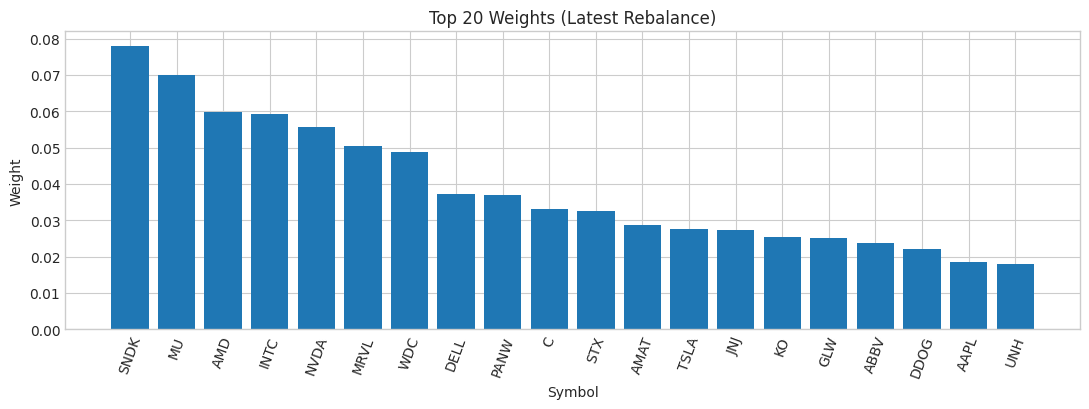

,symbol,latest_weight,prev_weight,delta_weight,abs_delta_weight
0,GLW,0.025118,7.980769e-08,0.025118,0.025118
1,AMAT,0.028781,3.978198e-03,0.024803,0.024803
2,ABBV,0.023784,1.263318e-05,0.023772,0.023772
3,DDOG,0.022071,0.000000e+00,0.022071,0.022071
4,AAPL,0.018640,4.064661e-02,-0.022006,0.022006
5,INTC,0.059281,3.755719e-02,0.021723,0.021723
6,JNJ,0.027336,5.989378e-03,0.021347,0.021347
7,KO,0.025374,5.632874e-03,0.019741,0.019741
8,MU,0.070116,5.336153e-02,0.016755,0.016755
9,LITE,0.014475,3.121613e-02,-0.016741,0.016741


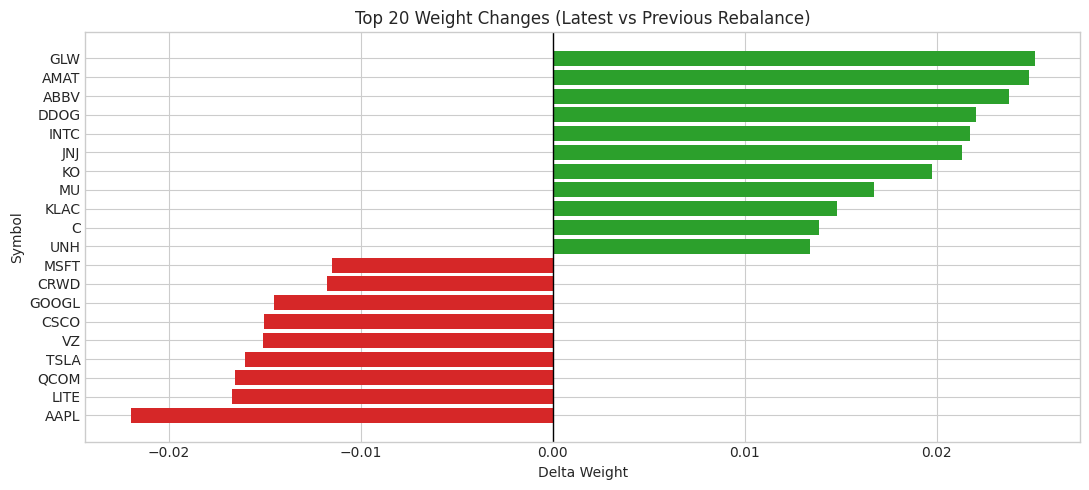

In [8]:
if weights_history is not None and len(weights_history) > 0:
    weight_cols = [c for c in weights_history.columns if c != 'trade_date']
    w_long = weights_history.melt(id_vars='trade_date', value_vars=weight_cols, var_name='symbol', value_name='weight')
    w_long['weight'] = pd.to_numeric(w_long['weight'], errors='coerce').fillna(0.0)
    w_long = w_long[w_long['weight'] > 0.0]
    latest_date = w_long['trade_date'].max()
    latest_w = w_long[w_long['trade_date'] == latest_date].sort_values('weight', ascending=False)
    prev_dates = sorted(d for d in w_long['trade_date'].unique() if d < latest_date)
    prev_date = prev_dates[-1] if prev_dates else None
    latest_total = float(latest_w['weight'].sum())
    hhi = float((latest_w['weight'] ** 2).sum())
    effective_n = (1.0 / hhi) if hhi > 0 else 0.0
    concentration = pd.DataFrame([
        {'metric': 'latest_trade_date', 'value': latest_date},
        {'metric': 'previous_trade_date', 'value': prev_date},
        {'metric': 'positions_count', 'value': int(len(latest_w))},
        {'metric': 'sum_weights', 'value': latest_total},
        {'metric': 'top_10_weight', 'value': float(latest_w['weight'].head(10).sum())},
        {'metric': 'top_20_weight', 'value': float(latest_w['weight'].head(20).sum())},
        {'metric': 'hhi', 'value': hhi},
        {'metric': 'effective_n', 'value': effective_n},
    ])
    display(concentration)
    display(latest_w.head(25).reset_index(drop=True))

    fig, ax = plt.subplots(figsize=(11, 4.2))
    topn = latest_w.head(20)
    ax.bar(topn['symbol'], topn['weight'])
    ax.set_title('Top 20 Weights (Latest Rebalance)')
    ax.set_xlabel('Symbol')
    ax.set_ylabel('Weight')
    ax.tick_params(axis='x', rotation=70)
    plt.tight_layout()
    plt.show()

    if prev_date is not None:
        prev_w = w_long[w_long['trade_date'] == prev_date][['symbol', 'weight']].rename(columns={'weight': 'prev_weight'})
        latest_comp = latest_w[['symbol', 'weight']].rename(columns={'weight': 'latest_weight'})
        weight_changes = latest_comp.merge(prev_w, on='symbol', how='outer').fillna(0.0)
        weight_changes['delta_weight'] = weight_changes['latest_weight'] - weight_changes['prev_weight']
        weight_changes['abs_delta_weight'] = weight_changes['delta_weight'].abs()
        weight_changes = weight_changes.sort_values('abs_delta_weight', ascending=False)
        display(weight_changes.head(25).reset_index(drop=True))

        fig, ax = plt.subplots(figsize=(11, 5.0))
        top_delta = weight_changes.head(20).sort_values('delta_weight')
        colors = ['#2ca02c' if v >= 0 else '#d62728' for v in top_delta['delta_weight']]
        ax.barh(top_delta['symbol'], top_delta['delta_weight'], color=colors)
        ax.axvline(0.0, color='black', linewidth=1)
        ax.set_title('Top 20 Weight Changes (Latest vs Previous Rebalance)')
        ax.set_xlabel('Delta Weight')
        ax.set_ylabel('Symbol')
        plt.tight_layout()
        plt.show()
    else:
        print('Only one rebalance snapshot is available; no weight-change comparison to display.')
else:
    print('weights_history.csv not found for selected run.')


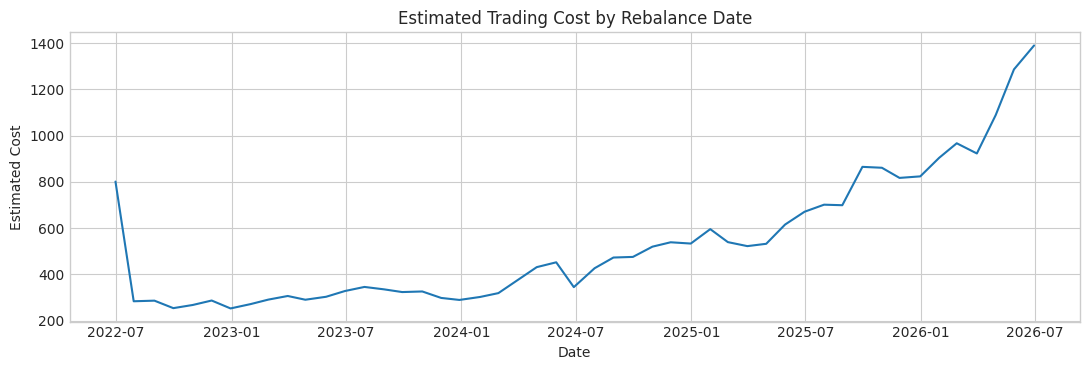

In [9]:
if orders_history is not None and len(orders_history) > 0 and 'trade_date' in orders_history.columns:
    o = orders_history.copy()
    o['notional'] = pd.to_numeric(o.get('notional', 0.0), errors='coerce').fillna(0.0)
    o['estimated_cost'] = pd.to_numeric(o.get('estimated_cost', 0.0), errors='coerce').fillna(0.0)
    daily_orders = o.groupby('trade_date', as_index=False).agg(
        orders_count=('symbol', 'size'),
        gross_notional=('notional', lambda x: float(x.abs().sum())),
        net_notional=('notional', 'sum'),
        estimated_cost=('estimated_cost', 'sum'),
    ).sort_values('trade_date')
   # display(daily_orders.tail(20))

    largest_orders = o.assign(abs_notional=o['notional'].abs()).sort_values('abs_notional', ascending=False)
   # display(largest_orders[['trade_date', 'symbol', 'action', 'delta_weight', 'notional', 'estimated_cost']].head(25))

    fig, ax = plt.subplots(figsize=(11, 3.8))
    ax.plot(daily_orders['trade_date'], daily_orders['estimated_cost'])
    ax.set_title('Estimated Trading Cost by Rebalance Date')
    ax.set_xlabel('Date')
    ax.set_ylabel('Estimated Cost')
    plt.tight_layout()
    plt.show()
else:
    print('orders_history.csv not found or missing trade_date column.')
